In [1]:
import sys
import os
sys.path.append(os.path.abspath('../scripts'))
from visualization import PhenologyVisualization
from functions import datenum_to_datetime
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

In [2]:
lakeid = 327
i , j = 23, 30

In [3]:
# version 3.1
pc_phenology_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\phenology\\phycocyanin\\{lakeid}.nc"
pc_extract_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\extract\\phycocyanin\\{lakeid}.nc"

chl_phenology_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\phenology\\chla\\{lakeid}.nc"
chl_extract_path_v3 = f"D:\\lakecci_data\\raw\\v3.1\\extract\\chla\\{lakeid}.nc"

In [4]:
PhenologyVisualization.set_shapefile_path(r"C:\Users\schelian\Downloads\lakes_cci_v2.1.0_shp\shapefile\lakescci_v2.1.0_data-availability.shp")

In [5]:
# load classes
phyco_v3 = PhenologyVisualization(pc_extract_path_v3, pc_phenology_path_v3)
chla_v3 = PhenologyVisualization(chl_extract_path_v3, chl_phenology_path_v3)

## Makes a legend

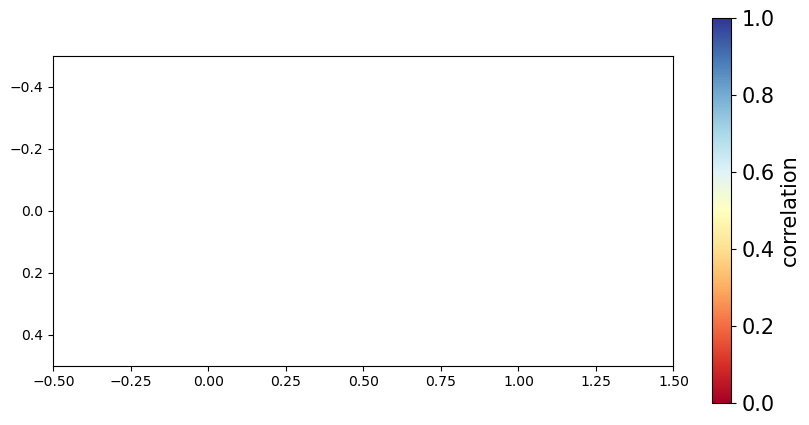

In [132]:
fig, ax = plt.subplots(1,1,figsize=(10,5))

img = plt.imshow(np.array([[0,1]]),cmap='RdYlBu')
img.set_visible(False)
cbar = plt.colorbar(orientation='vertical')
cbar.set_label( label='correlation',size=15)
cbar.ax.tick_params(labelsize=15)

## Interactive plotting

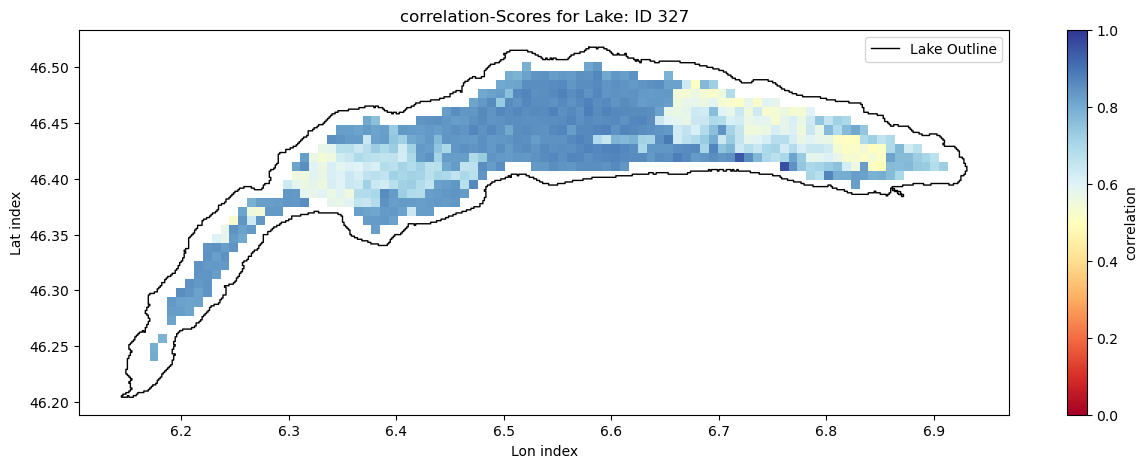

In [13]:
fig, ax = plt.subplots(1,1,figsize=(15,5))
phyco_v3.metric_map(phyco_v3.correlation_scores(),'correlation',fig,ax,'RdYlBu')

## Standard times series plots

In [27]:

plt.rcParams["axes.labelsize"] = 12

plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

c:\Users\schelian\cci-cyano-production\scripts\visualization.py:1940: Warning: Negative Troughs(s) in time period 2003-2012
  warnings.warn(f"Negative Troughs(s) in time period {start}-{end}", Warning)
c:\Users\schelian\cci-cyano-production\scripts\visualization.py:1951: Warning: Negative Mid Up(s) in time period 2003-2012
  warnings.warn(f"Negative Mid Up(s) in time period {start}-{end}", Warning)


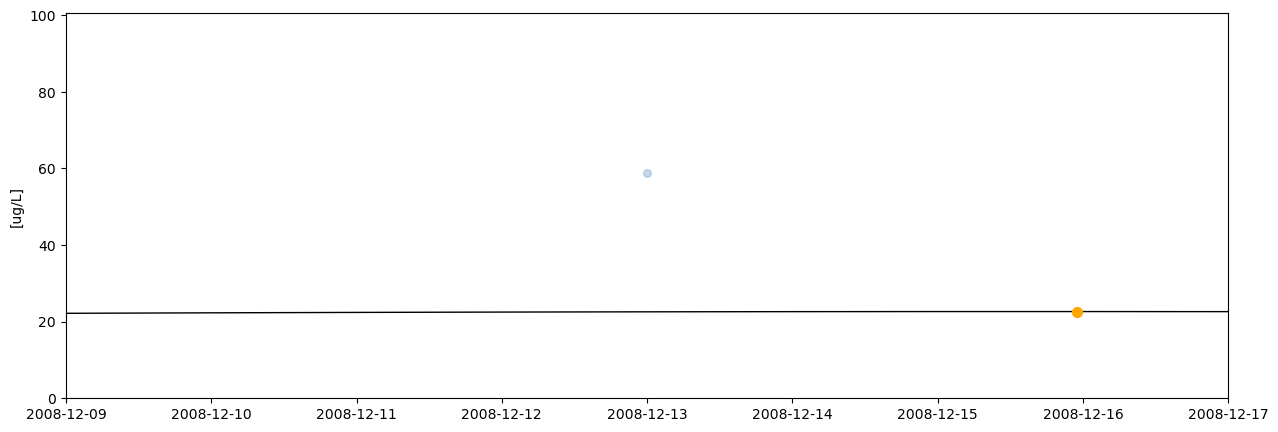

In [28]:
fig, ax = plt.subplots(1,1,figsize=(15,5))

phyco_v3.single_plot(i,j, ax, aggregation=True,start=2003, end= 2012)
ax.collections[0].set(color = 'steelblue')
ax.collections[0].set_sizes([30])
# chla_v3.single_plot(155,306, ax, aggregation=False, start=2003,end= 2012)
# ax.collections[-5].set(color = 'orangered',sizes=[30])
for txt in ax.texts:
    txt.remove()
ax.get_legend().remove()
ax.set_xlim(pd.to_datetime("09-12-2008", format= "%d-%m-%Y"), pd.to_datetime("17-12-2008", format= "%d-%m-%Y"))
ax.set_ylim(0,100.5)
ax.set_title("")
ax.grid()

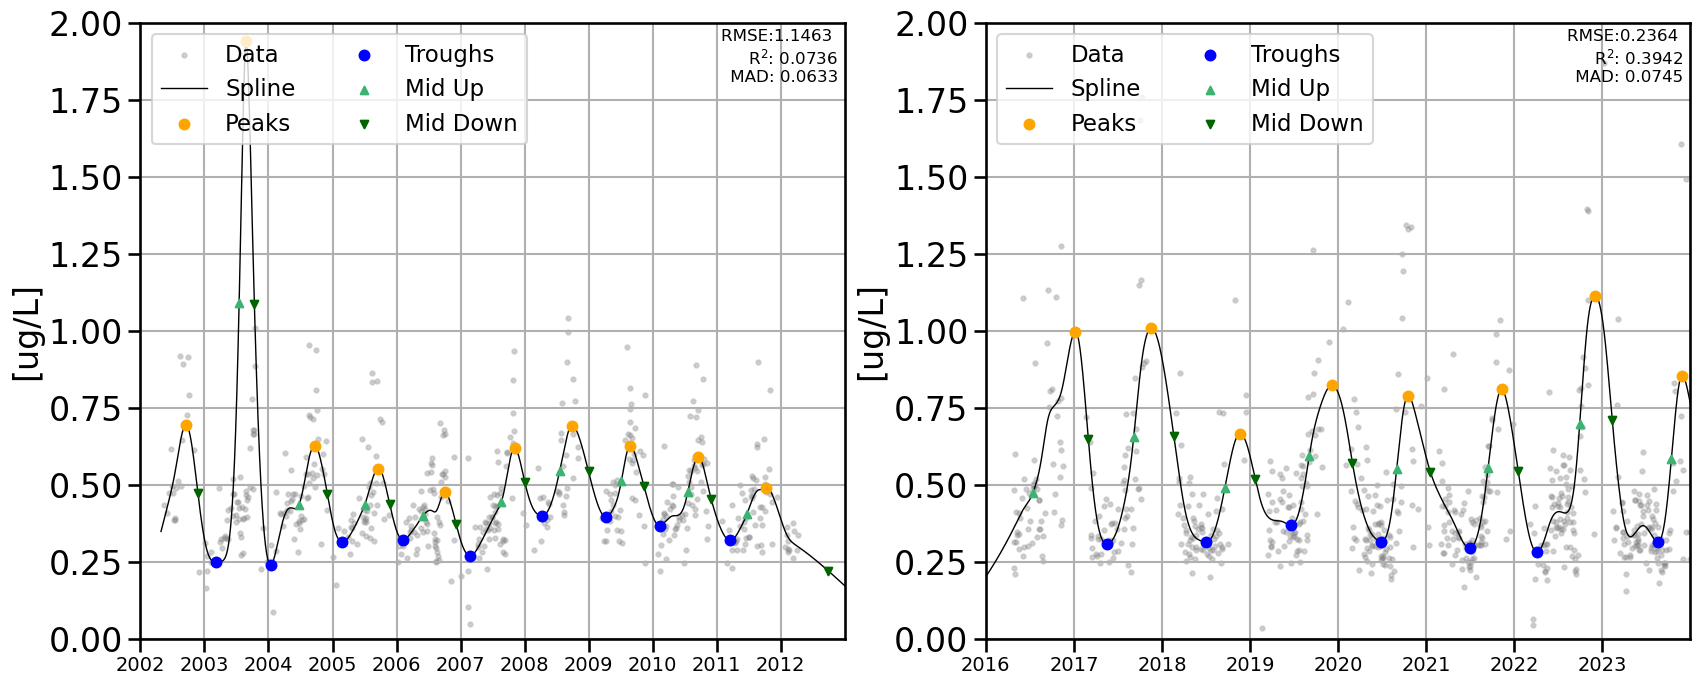

In [ ]:

fig, axs = plt.subplots(1,2, figsize = (20,8))

chla_v3.split_plot(ax0 = axs[0], ax1=axs[1],latitude = i,longitude = j, aggregation=False,end0 = 2012,start1 = 2016)
axs[0].set_title("")
axs[1].set_title("")
axs[0].set_ylim(0,2)
axs[1].set_ylim(0,2)


axs[0].texts[0].set_fontsize(12)
axs[1].texts[0].set_fontsize(12)


In [ ]:
fig, ax = plt.subplots(1,1,figsize=(15,5))

chla_v3.single_plot(137,312, ax, aggregation=False,start=2003, end= 2012)

## Basic map

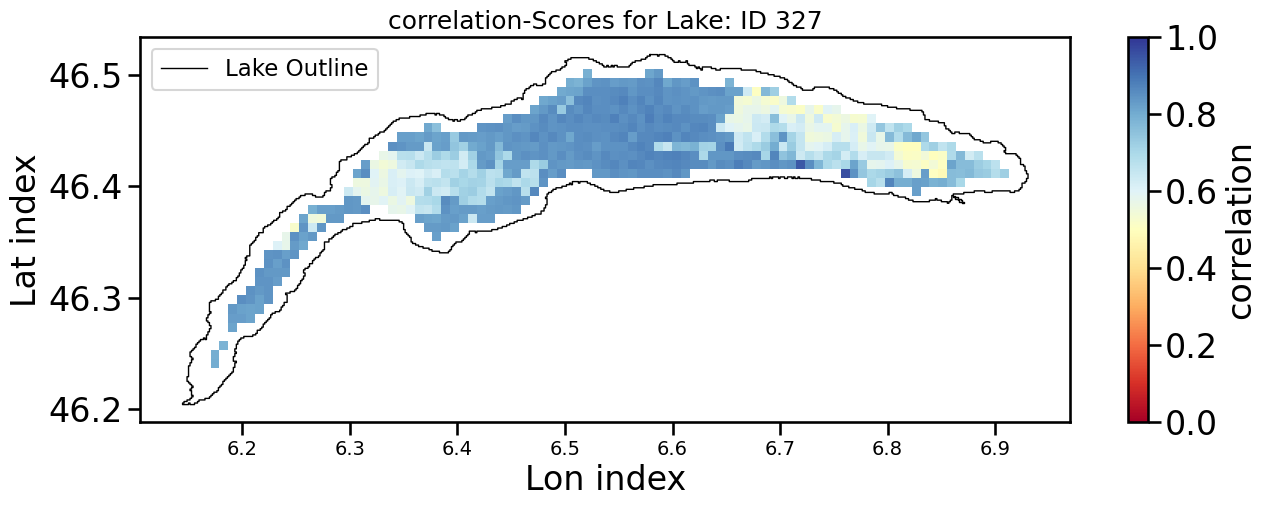

In [269]:
fig, ax = plt.subplots(1,1,figsize=(15,5))
phyco_v3.metric_map(phyco_v3.correlation_scores(),'correlation',fig,ax,'RdYlBu')

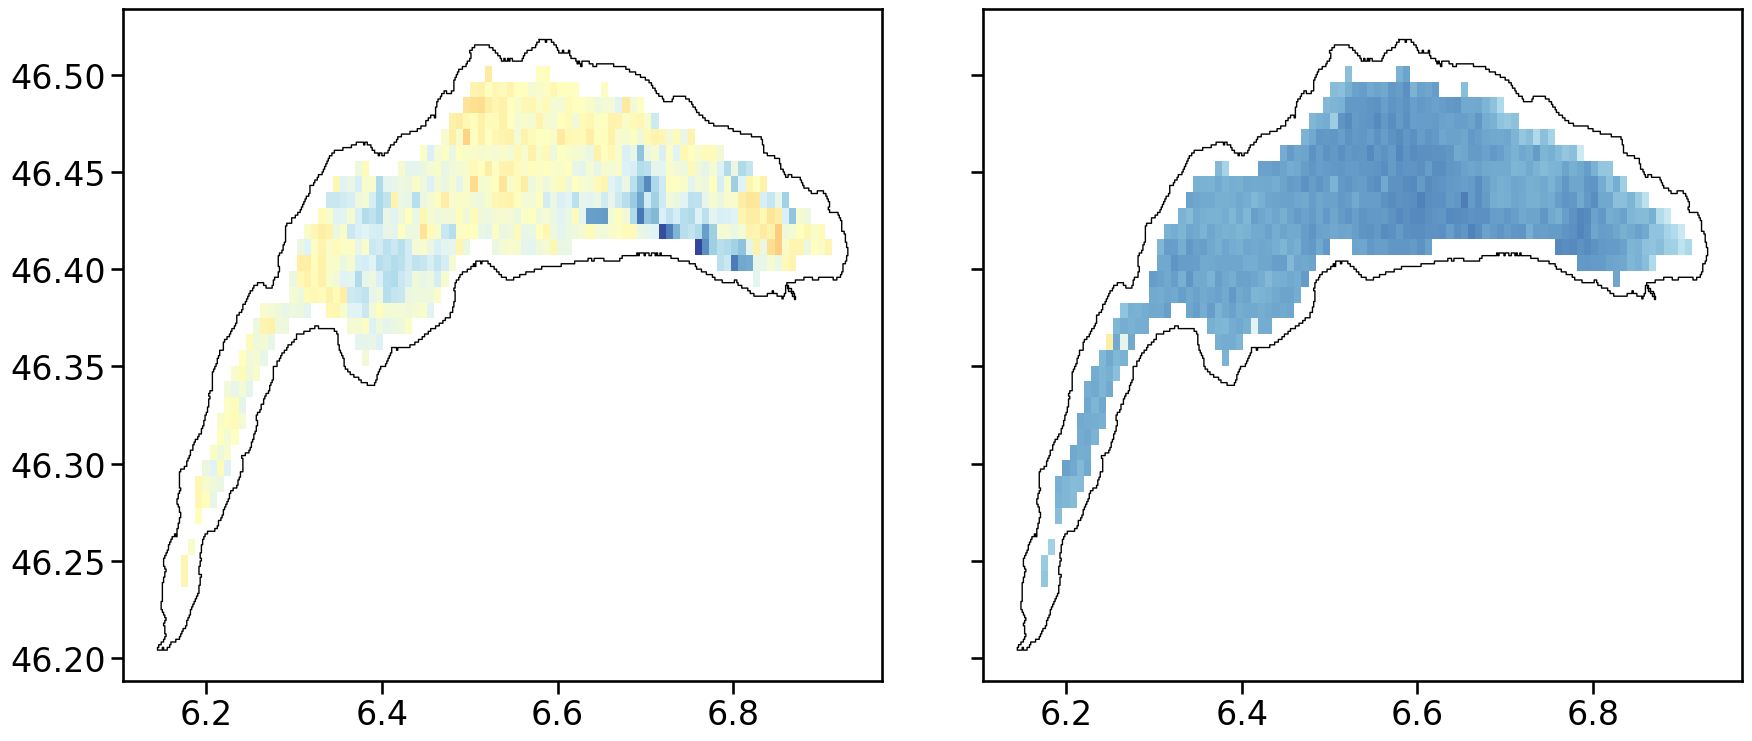

In [316]:
fig, axs = plt.subplots(1,2, figsize = (20,8))
cmap = 'RdYlBu'
colorbar_extent = [0,1]
phyco_v3.metric_map(phyco_v3.correlation_scores(end= 2012),'RMSE', fig, axs[0],cmap, colorbar_extent= colorbar_extent)
phyco_v3.metric_map(phyco_v3.correlation_scores(start= 2016),'RMSE', fig, axs[1],cmap, colorbar_extent= colorbar_extent)

fig.axes[-1].remove()
fig.axes[-1].remove()

axs[0].set_xlabel('')
axs[1].set_xlabel('')
axs[0].set_ylabel('')
axs[1].set_ylabel('')

axs[1].set_yticklabels([])
axs[0].get_legend().remove()
axs[1].get_legend().remove()
axs[0].set_title('')
axs[1].set_title('')
plt.tight_layout()

## Zoom in of peaks

with optional date highlighting

Used to compare against Mortimer's POLYMER processing

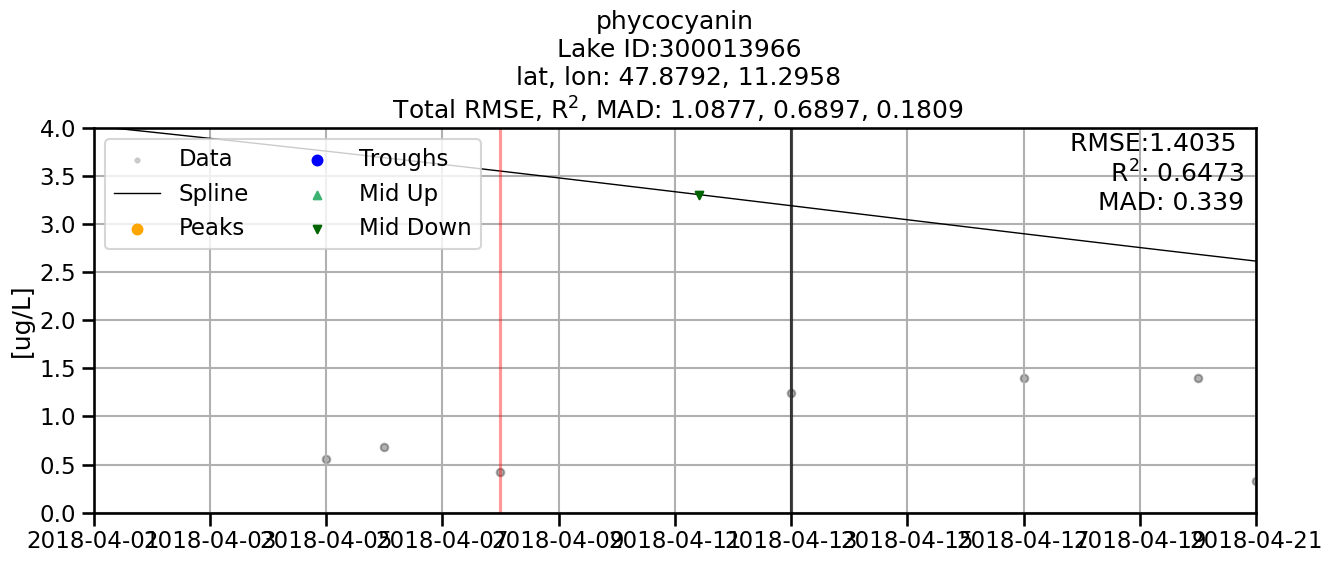

In [88]:
fig, ax = plt.subplots(1,1,figsize=(15,5))

phyco_v3.single_plot(7,3, ax, aggregation=True, start=2018, end= 2018)
ax.set_xlim(pd.to_datetime("01-04-2018", format= "%d-%m-%Y"), pd.to_datetime("21-04-2018", format= "%d-%m-%Y"))
ax.set_ylim(0,4)

ax.collections[0].set(color = 'black')
ax.collections[0].set_sizes([30])
ax.axvline(x=pd.to_datetime("08-04-2018", format= "%d-%m-%Y"),alpha = 0.4, c= "red")
ax.axvline(x=pd.to_datetime("13-04-2018", format= "%d-%m-%Y"),alpha = 0.7, c = "black")
# ax.axvline(x=pd.to_datetime("09-01-2022", format= "%d-%m-%Y"),alpha = 0.4, c= "purple")
# ax.axvline(x=pd.to_datetime("28-01-2022", format= "%d-%m-%Y"),alpha = 0.4, c= "purple")

## 1:1 plot

In [187]:
import seaborn as sns
import netCDF4

## Single day plots

In [12]:
manual_date = pd.to_datetime("13-12-2008", format= "%d-%m-%Y")
print(manual_date)
phyco_v3.single_day_map(manual_date)

2008-12-13 00:00:00


ValueError: Date 2008-12-13 00:00:00 not found in the extract time axis.

2008-12-13 00:00:00+00:00


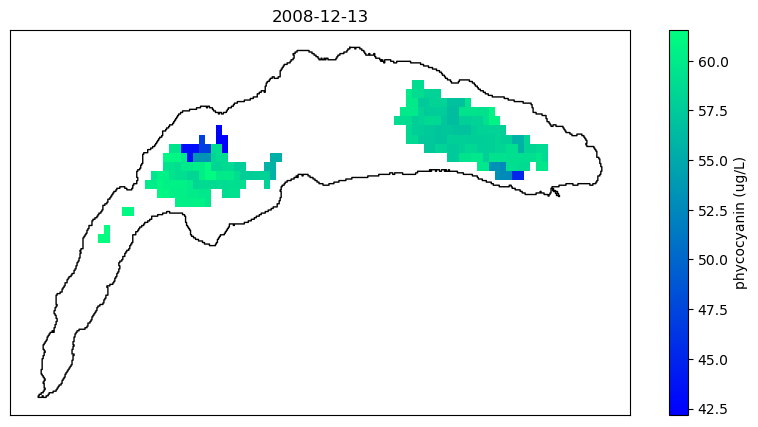

In [13]:
print(series.idxmax())
phyco_v3.single_day_map(series.idxmax())

In [ ]:
phyco_v3.single_day_map(series.idxmax())

-15: no data
-14: no data
-13: no data
-12: no data
-11: no data
-10: no data
-9: no data
-8: no data
-7: no data
-4: no data
-3: no data
-2: no data
-1: no data
1: no data
2: no data
3: no data
4: no data
5: no data
6: no data
7: no data
8: no data
9: no data
12: no data


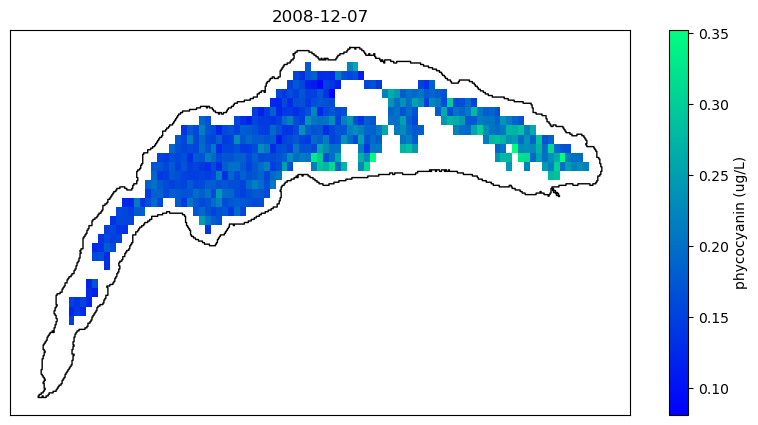

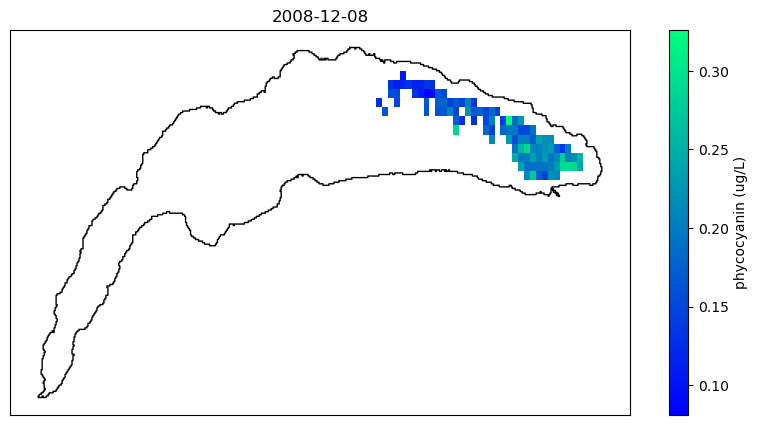

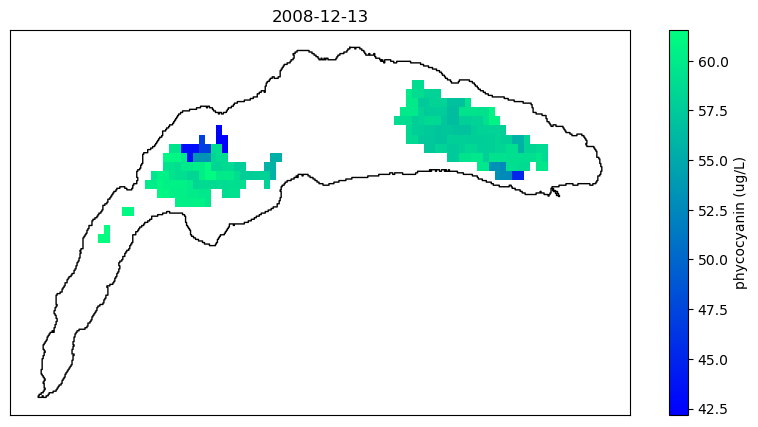

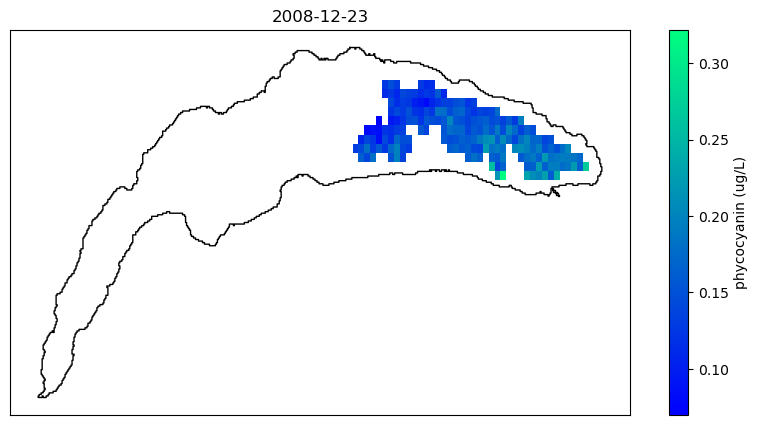

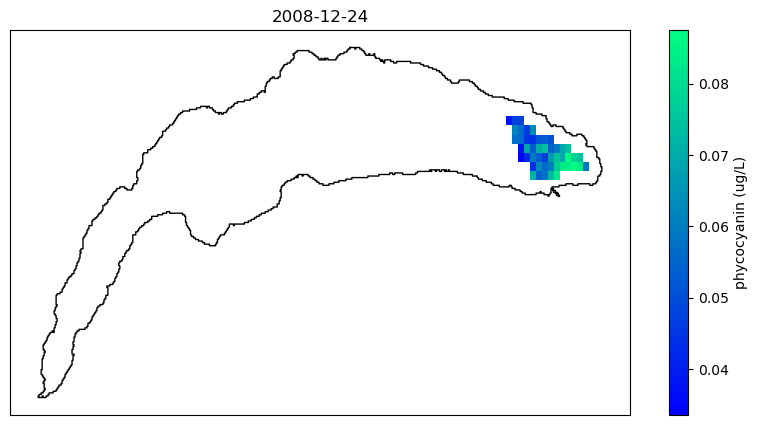

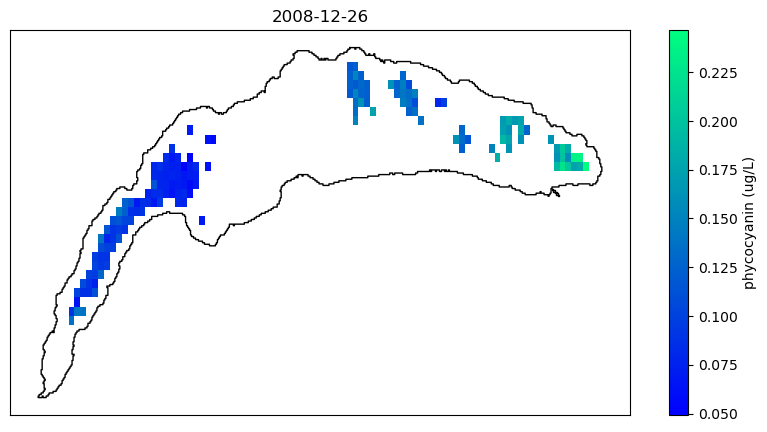

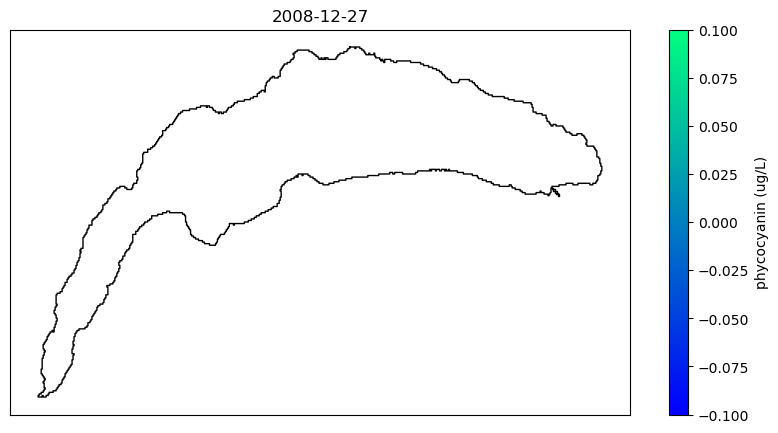

In [6]:
series = phyco_v3.load_pixel_data(i, j)
for d in np.arange(-15,15):
    try:
        phyco_v3.single_day_map(series.idxmax()+pd.Timedelta(d,"D"))
    except Exception:
        print(str(d)+": no data")

## Hard-coded Lake Superior plot. Do not delete.

In [ ]:
bad_pixel_series = chla_v3.load_pixel_data(158,668)
bad_date = chla_v3._extracted_globals['t_all'][datenum_to_datetime(chla_v3._extracted_globals['t_all']) ==bad_pixel_series.idxmax()]
np.argwhere(datenum_to_datetime(chla_v3._extracted_globals['t_all']) ==bad_pixel_series.idxmax())

array([[258]])

In [ ]:
g = chla_v3._load_extracted_globals()
with netCDF4.Dataset(chla_v3.e_path) as nc:
                                values = np.array(nc.variables[g["variable"]][258, :, :])
                                qa     = np.array(nc.variables[g["qa"]][258, :, :])

mask = (values != -9999) & (qa == 0)

In [ ]:
lake_row = chla_v3.geom[chla_v3.geom["id"] == lakeid]
geom = lake_row.geometry.iloc[0]

shapely.geometry.multipolygon.MultiPolygon

Text(0.5, 1.0, '2003-08-25 00:00:00+00:00')

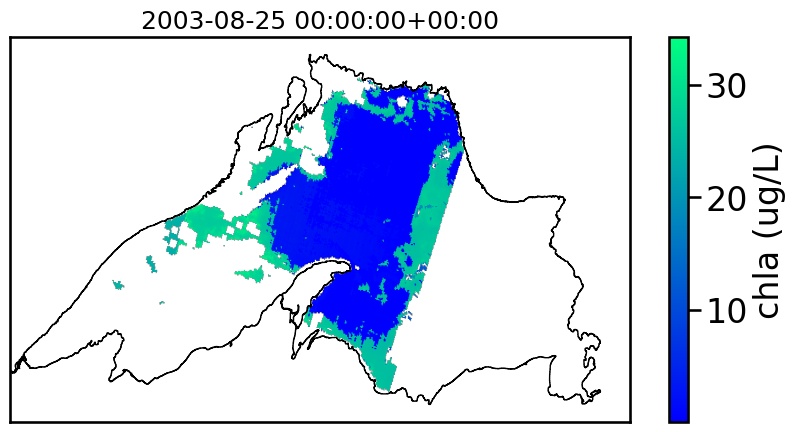

In [262]:
fig, ax = plt.subplots(1,1,figsize=(10,5))
with netCDF4.Dataset(chla_v3.e_path) as nc:
        summary = np.array(nc.variables["summary"][:, :])
        lats = nc.variables["lat"][:]
        lons = nc.variables["lon"][:]
        map_data = np.where(mask, values, np.nan)
        cmap = "winter"
        im = ax.imshow(map_data, cmap=cmap, aspect="auto", origin="lower", extent=[lons.min(), lons.max(), lats.min(), lats.max()])
        for poly in geom.geoms:
                        x, y = poly.exterior.xy
                        label = "Lake Outline" if not label else None
                        ax.plot(x, y, color="black", linewidth=1, label = label)
                        label = True
fig.colorbar(im,orientation='vertical',label='chla (ug/L)')
plt.xticks([])
plt.yticks([])
plt.title(datenum_to_datetime(bad_date).astype(str)[0])

(0.0, 3.0)

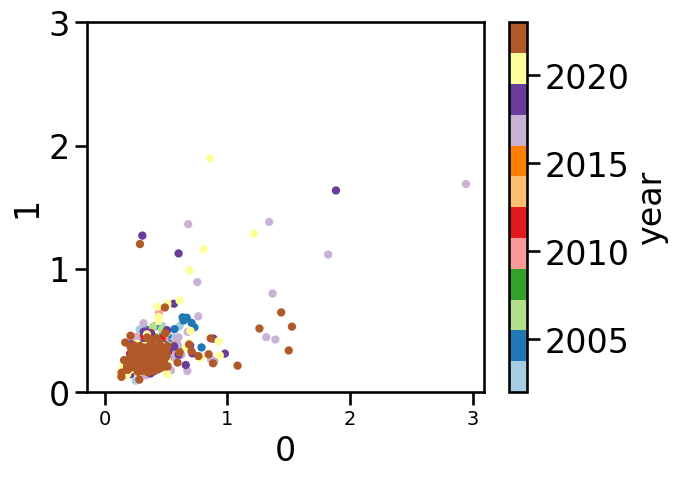

In [119]:
combo_df = pd.concat([good_pixel_series,bad_pixel_series],axis=1).dropna(axis=0)
combo_df['year']= combo_df.index.year
combo_df.plot(kind='scatter',x=0,y=1,c='year',cmap='Paired')
plt.ylim(0,3)

In [102]:
bad_pixel_series.index

DatetimeIndex(['2002-05-22 00:00:00+00:00', '2002-05-24 00:00:00+00:00',
               '2002-06-03 00:00:00+00:00', '2002-06-22 00:00:00+00:00',
               '2002-07-01 00:00:00+00:00', '2002-07-02 00:00:00+00:00',
               '2002-07-11 00:00:00+00:00', '2002-07-18 00:00:00+00:00',
               '2002-07-24 00:00:00+00:00', '2002-08-06 00:00:00+00:00',
               ...
               '2023-09-24 00:00:00+00:00', '2023-09-27 00:00:00+00:00',
               '2023-09-28 00:00:00+00:00', '2023-09-29 00:00:00+00:00',
               '2023-10-02 00:00:00+00:00', '2023-10-03 00:00:00+00:00',
               '2023-10-05 00:00:00+00:00', '2023-11-15 00:00:00+00:00',
               '2023-11-20 00:00:00+00:00', '2023-12-29 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', length=1090, freq=None)

In [ ]:

phyco_series = phyco_v3.load_pixel_data(i,j)
chla_series = chla_v3.load_pixel_data(i,j)
meris_sensor = chla_series.index.year < 2013

In [9]:
df_to_plot = pd.concat([chla_series,phyco_series],axis=1)
df_to_plot.columns = ['chla','phyco']
df_to_plot['year'] = df_to_plot.index.year
df_to_plot['meris_period'] = df_to_plot['year'] < 2013

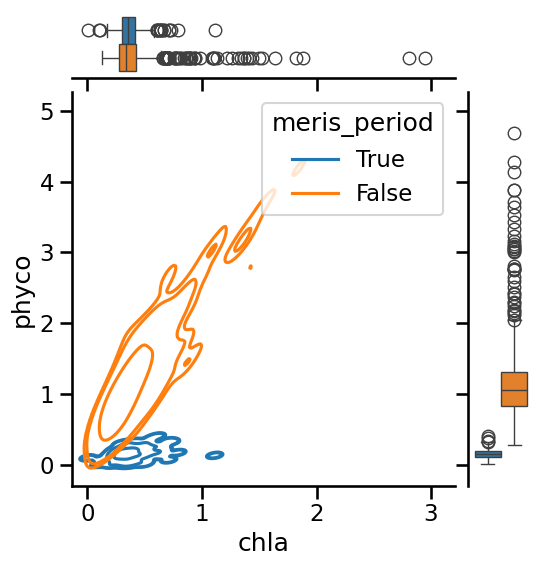

In [27]:
sns.set_context("talk")
g = sns.JointGrid(df_to_plot, x= "chla",y="phyco",hue="meris_period",hue_order=[True,False],height=6)
g.plot_joint(sns.kdeplot,levels=[0.005,0.01,0.1,0.5])
g.plot_marginals(sns.boxplot)